# ✍️ Writer ID — 수동 crop 전용 파이프라인

`baseline (1).ipynb`의 ResNet18 구조를 따르되, **학습 데이터를 사람이 직접 잘라낸
손글씨 crop(`crop_labeling.zip`)으로만** 바꾼 버전이다. 슬라이드 인쇄체·페이지 배경이
들어오지 않으므로 "필체가 아닌 것"을 외울 여지가 구조적으로 없다.

## 이전 시도에서 배운 것 (전부 실측)

| 사실 | 값 | 근거 |
|---|---|---|
| 균등 무작위 제출의 LB | **0.11796** | 490행에 클래스를 49개씩 순환 배정해 실제 제출 |
| 지금까지 최고 제출 | 0.13254 | 무작위 대비 +0.015 — **노이즈 범위** |
| 마스킹+SupCon 제출 | 0.08734 | 무작위보다 낮음. 예측이 ysh 49%로 붕괴 |
| 테스트 복호화 | 정상 | 인접 픽셀 상관 0.918 (암호문이면 0 근처) |
| 테스트 타일 획 두께 | **7.19px** | distance transform p90×2, 490장 중앙값 |
| 테스트 타일 잉크 비율 | 0.0696 | 동일 표본 |
| 다크모드 테스트 타일 | 12.2% | 학습 페이지는 829장 중 8장(1.0%), 전부 ysh |

**결론: 아직 무작위를 유의미하게 넘은 모델이 없다.** LB 차이 0.02 이내는 개선으로 보지 않는다.

## 이 노트북이 다르게 하는 것 — 획 두께 정규화

수동 crop을 1:1 원본 배율로 재면 writer마다 획 두께가 **4.00 ~ 8.00px**로 2배 차이가 난다.
페이지 원본 해상도가 writer마다 다르기 때문이다(ehj 1008px ~ ysh 4999px).

```
csb 6.39   csh 4.39   ehj 4.00   lc 4.39   sj 4.00
sy  6.00   wj  4.39   yh  4.00   ys  8.00   ysh 6.39     (px, 중앙값)
```

즉 **획 두께만 봐도 writer를 상당히 맞힐 수 있다.** 모델이 배우기 가장 쉬운 특징이고,
학습 데이터에서는 잘 통한다. 그런데 테스트 타일은 전부 같은 방식으로 생성되어 획 두께가
7.19px로 균일하다 — 그 지름길이 통째로 사라진다. 지금까지 모든 제출이 무작위 수준이었던 것과
train 0.70 / val 0.20 격차가 이 하나로 설명된다.

그래서 이 노트북은 **모든 이미지(학습 crop과 테스트 타일 모두)를 획 두께가 같아지도록
리스케일한 뒤** 패치를 뜬다. 해상도 지름길을 제거하는 동시에 두 도메인의 배율을 맞춘다.
여기에 획 두께 무작위 변형을 증강으로 얹어, 남은 두께 신호에도 기대지 못하게 한다.

## 검증 설계

crop의 원본 페이지를 알면 그 페이지의 **촬영 세션**을 물려받는다. 세션 단위로 분할해야
"같은 날 같은 펜"이 train과 val 양쪽에 들어가는 누수를 막는다. 파일명이 `writer_NNNN`인
crop은 원본을 바로 알 수 있고, timestamp 이름은 `crop_source_map.csv`(템플릿 매칭 결과)로
복원한다. 둘 다 실패하면 학습에만 쓰고 val에서는 제외한다.

## v3 — 태블릿 렌더링 시뮬레이션

진행자 확인: 테스트 손글씨는 종이를 찍은 사진이 아니라 **태블릿 스타일러스로 쓴 디지털
잉크**다. 학습 crop(볼펜 손글씨 사진)과 구조적으로 다른 점이 최소 두 가지다.

1. 스타일러스 앱은 벡터 렌더링이라 획 가장자리가 안티에일리어싱으로 매끈한데, 종이
   사진은 종이 결·잉크 번짐으로 가장자리가 거칠다.
2. 필압 감지 앱은 획 시작/끝(펜을 대고 떼는 순간)이 가늘어지는 테이퍼링을 렌더링하는데,
   볼펜 손글씨는 이 효과가 약하다.

둘 다 **학습에는 없고 테스트에는 있을 수 있는 특징**이라, v2까지의 두께/잉크/배경
정규화와 같은 논리로 학습 쪽에 흉내를 추가해 도메인 갭을 줄인다
(`simulate_aa_blur`, `simulate_stroke_taper`, cell [6]/[7]). 배경 합성(v2)은 그대로
둔다 — 태블릿 필기 앱도 줄노트/모눈/오선 테마를 실제로 제공하므로 가정이 여전히 유효하다.

## v5 — ConvNeXt-Tiny 백본

v4(ArcFace)는 val macro F1은 괜찮았지만 LB가 0.16320으로 오히려 악화됐다 — SupCon
때와 같은 계열의 실패로, 마진 기반 학습이 train/val(둘 다 사진 도메인)에서만 통하는
지름길을 더 세게 붙잡은 것으로 보인다. 그래서 v5는 손실 함수 대신 **백본**을 바꾼다.

ImageNet-학습 CNN은 형태보다 텍스처에 편향된다는 보고가 있다(Geirhos et al., ICLR
2019) — 이 태스크의 domain gap이 정확히 '종이 잉크의 국소 텍스처 vs 태블릿 벡터
렌더링의 매끈함'이라, 텍스처 편향이 강한 백본일수록 이 갭에 더 취약할 수 있다. 순수
ViT는 저데이터 미세조정에서 CNN보다 떨어진다는 벤치마크가 많아 제외했고, 대신 큰
커널·LayerNorm 등 트랜스포머적 설계를 CNN에 접목한 **ConvNeXt-Tiny**를 골랐다 —
저데이터 미세조정과 분포 이동 강건성 모두에서 EfficientNetV2보다도 낫다고 보고된다.
헤드는 v4의 ArcFace가 아니라 v1~v3과 같은 단순 Linear+CrossEntropy로 되돌려
변수를 하나만 바꾼다(백본 교체 효과와 헤드 교체 효과가 섞이지 않도록).


In [15]:
# [1] 임포트 · 시드 · 디바이스
import os, sys, glob, json, math, random, re, shutil, subprocess, time, zipfile
from collections import Counter

# v5: benchmark=False로도 안 풀리는 "GET was unable to find an engine" 오류 —
# ConvNeXt의 depthwise conv와 Colab cuDNN v8 API 조합에서 보고된 알려진 버그다.
# torch를 임포트하기 전에 v8 API 자체를 꺼서 v7 경로로 우회한다.
os.environ["TORCH_CUDNN_V8_API_DISABLED"] = "1"

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
from skimage.morphology import skeletonize
from scipy.ndimage import convolve

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU")
if DEVICE.type == "cuda":
    # v5: ConvNeXt의 depthwise 7x7 conv + cudnn.benchmark 조합이 Colab cuDNN에서
    # "FIND was unable to find an engine" 오류를 낸다(널리 보고된 이슈). ResNet18은
    # 이 조합에 안 걸렸는데 백본을 바꾸며 드러났다 — benchmark 탐색을 끈다.
    torch.backends.cudnn.benchmark = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    if not os.path.isdir("/content/drive"):
        drive.mount("/content/drive")

device: cuda NVIDIA L4


In [16]:
# [2] CONFIG — 모든 경로/하이퍼파라미터는 이 셀에만 둔다
CFG = dict(
    # ---- 경로 ----
    DRIVE_ROOT       = "/content/drive/MyDrive/AIKUTHON",
    CROP_ZIP_PATH    = "/content/drive/MyDrive/AIKUTHON/crop_labeling.zip",
    DATA_ZIP_PATH    = "/content/drive/MyDrive/AIKUTHON/12-aikuthon.zip",
    TEST_LOADER_PATH = "/content/drive/MyDrive/AIKUTHON/test_loader.ipynb",
    SOURCE_MAP_PATH  = "/content/drive/MyDrive/AIKUTHON/crop_source_map.csv",
    CROP_DIR         = "/content/crop_labeling",
    UNZIP_BASE       = "/content/data",
    # 설정을 바꿀 때마다 함께 바꾼다 — 이전 실행의 best.pt/submission.csv를 덮어쓰지 않고
    # 제출 점수와 설정을 나중에 짝지을 수 있다.
    # (v1 = 획 두께 정규화만, public LB 0.14991 / v2 = +잉크밀도+배경합성, public LB 0.30232 /
    #  v3 = +태블릿 렌더링 시뮬레이션(진행중) / v4 = v3+ArcFace, public LB 0.16320(악화,
    #  train/val에서만 통하는 지름길을 마진이 더 세게 붙잡은 것으로 추정) /
    #  v5 = v3 헤드는 되돌리고 백본만 ConvNeXt-Tiny로 교체, 아직 미제출)
    RUN_NAME         = "crop_convnext_v5_backbone",

    # ---- 획 두께 정규화 (이 노트북의 핵심) ----
    # 복호화 테스트 타일 490장의 획 두께 중앙값. 모든 이미지를 이 값에 맞춘다.
    TARGET_STROKE_PX = 7.19,
    STROKE_JITTER    = (0.80, 1.25),  # 정규화 오차에 견디도록 학습 시 배율을 흔든다
    MIN_STROKE_PX    = 1.5,           # 측정 실패로 판단하는 하한 (그 경우 정규화 생략)
    MAX_RESCALE      = 4.0,           # 극단 확대/축소로 이미지가 깨지는 것을 막는다
    NORM_PASSES      = 4,             # 배율 반복 보정 횟수 (1회로는 목표에 못 미친다)

    # ---- 패치 ----
    # 224에서는 학습 crop의 54%가 배경 패딩을 받는데 테스트 타일(512px)은 0%다.
    # 160으로 줄이면 43%로 낮아지고 crop당 뽑을 수 있는 패치도 늘어난다.
    PATCH        = 160,
    BG_VALUE     = 235,          # to_gray_normalized 이후의 배경 밝기
    # 잉크 밀도 정규화 — 획 두께에 이어 두 번째 지름길을 막는다.
    # 정규화 후 패치 잉크 비율이 writer마다 0.056~0.128로 갈렸고(사람이 얼마나 타이트하게
    # 잘랐는지가 만든 아티팩트), 테스트 타일(0.077)에 가장 가까운 ys가 테스트 예측의 60%를
    # 가져갔다. 그래서 학습·검증·추론 모두 목표 잉크 밀도에 가까운 위치에서 패치를 고른다.
    TARGET_INK       = 0.077,    # 복호화 테스트 패치 820개의 잉크 비율 중앙값
    INK_JITTER       = 0.020,    # 학습 시 목표를 이만큼 흔들어 특정 값에 고착되지 않게 한다
    PATCH_CANDIDATES = 24,       # 학습: 무작위 후보 수. 이 중 잉크가 목표에 가까운 것을 고른다
    PATCH_TOPK       = 8,        # 상위 후보 풀 크기 (학습은 이 안에서 무작위 선택)

    # ---- 배경 증강 ----
    # 진행자 힌트: 테스트는 인쇄체 없이 글씨만 있고, 배경은 오선줄·줄노트·누런 종이·색지 등
    # 다양하다. 수동 crop은 원본 페이지 배경을 그대로 갖고 있어 배경이 곧 세션 지문이 된다.
    # 잉크만 남기고 배경을 무작위로 갈아끼워 배경 자체를 학습 단서에서 제거한다.
    SYNTH_BG_P  = 0.60,          # 학습 crop을 합성 배경에 얹을 확률
    # 복호화 테스트 타일의 12.2%가 다크모드 판정을 받는데 학습 페이지는 1.0%뿐이다(전부 ysh).
    # 그대로 두면 "어두운 배경 = ysh"를 외운다. 촬영 단계에서 반전시켜 같은 경로를 타게 한다.
    DARK_SIM_P  = 0.15,
    # ---- 태블릿 렌더링 시뮬레이션 (v3) ----
    # 테스트는 종이 사진이 아니라 태블릿 스타일러스 디지털 잉크다(진행자 확인). 벡터
    # 렌더링의 안티에일리어싱과 필압 테이퍼링은 학습 사진 데이터에는 없는 특징이라,
    # 흉내를 증강으로 추가해 그 갭을 줄인다.
    AA_BLUR_P           = 0.5,           # crop에 안티에일리어싱 블러를 적용할 확률
    AA_BLUR_SIGMA       = (0.4, 1.0),    # 가우시안 시그마 범위 (px)
    TAPER_P             = 0.5,           # 획 끝 테이퍼링을 적용할 확률
    TAPER_RADIUS        = (4.0, 10.0),   # 끝점 -> 배경으로 흐려지는 반경 (px)
    TAPER_MAX_ENDPOINTS = 12,            # crop 1장당 처리할 끝점 수 상한 (속도 보호)

    TRAIN_PATCHES_PER_CROP = 4,  # 학습 시 crop 1장에서 뽑는 패치 수
    VAL_PATCHES_PER_CROP   = 3,  # 검증 시 (결정적)
    TEST_PATCHES_PER_TILE  = 5,  # 추론 시 (중앙 + 4분면)

    # ---- 학습 ----
    EPOCHS          = 20,
    BATCH_SIZE      = 96,        # crop 단위 배치 (실제 샘플 = BATCH_SIZE × PATCHES_PER_CROP)
    # ConvNeXt는 ResNet보다 학습률에 민감하고(LayerNorm 기반) 파라미터도 2배 이상
    # 많아(28M) 작은 데이터셋에서 과적합 위험이 더 크다. 공식 미세조정 레시피를 따라
    # LR을 낮추고 weight decay를 올렸다 — v3(ResNet18, LR 3e-4/wd 1e-4)와 직접 비교는
    # 어렵지만, val 커브를 보고 우선 조절할 값이다.
    LR              = 5e-5,
    WEIGHT_DECAY    = 0.05,
    LABEL_SMOOTHING = 0.05,
    IMBALANCE_POWER = 0.5,       # 샘플러 가중치 = count^(1-POWER)/count. 1.0=완전 균등
    EARLY_STOP_PATIENCE = 6,
    NUM_WORKERS     = 0,         # Colab Python 3.13 multiprocessing 종료 오류 회피

    # ---- 검증 ----
    VAL_CROP_FRAC    = 0.25,     # writer마다 crop의 이 비율만큼을 세션 단위로 val에 뗀다
    USE_UNMAPPED_IN_TRAIN = True,  # 원본을 못 찾은 crop을 학습에만 쓸지

    # ---- 실행 모드 ----
    SMOKE_TEST = False,
)
CFG["OUT_DIR"] = f"/content/outputs_{CFG['RUN_NAME']}"
CFG["DRIVE_OUT_DIR"] = os.path.join(CFG["DRIVE_ROOT"], f"outputs_{CFG['RUN_NAME']}")
os.makedirs(CFG["OUT_DIR"], exist_ok=True)

CLASSES = ["csb", "csh", "ehj", "lc", "sj", "sy", "wj", "yh", "ys", "ysh"]
LABEL_MAP = {w: i for i, w in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

# 실측 무작위 바닥값. 모든 판단의 기준선이며 이보다 낮으면 모델이 해를 끼치고 있다는 뜻이다.
RANDOM_FLOOR_LB = 0.11796

if CFG["SMOKE_TEST"]:
    CFG["EPOCHS"] = 2
print(json.dumps({k: v for k, v in CFG.items() if not k.endswith("PATH")}, indent=2, ensure_ascii=False))

{
  "DRIVE_ROOT": "/content/drive/MyDrive/AIKUTHON",
  "CROP_DIR": "/content/crop_labeling",
  "UNZIP_BASE": "/content/data",
  "RUN_NAME": "crop_resnet18_v2_inknorm_bgaug",
  "TARGET_STROKE_PX": 7.19,
  "STROKE_JITTER": [
    0.8,
    1.25
  ],
  "MIN_STROKE_PX": 1.5,
  "MAX_RESCALE": 4.0,
  "NORM_PASSES": 4,
  "PATCH": 160,
  "BG_VALUE": 235,
  "TARGET_INK": 0.077,
  "INK_JITTER": 0.02,
  "PATCH_CANDIDATES": 24,
  "PATCH_TOPK": 8,
  "SYNTH_BG_P": 0.6,
  "DARK_SIM_P": 0.15,
  "TRAIN_PATCHES_PER_CROP": 4,
  "VAL_PATCHES_PER_CROP": 3,
  "TEST_PATCHES_PER_TILE": 5,
  "EPOCHS": 20,
  "BATCH_SIZE": 96,
  "LR": 0.0003,
  "WEIGHT_DECAY": 0.0001,
  "LABEL_SMOOTHING": 0.05,
  "IMBALANCE_POWER": 0.5,
  "EARLY_STOP_PATIENCE": 6,
  "NUM_WORKERS": 0,
  "VAL_CROP_FRAC": 0.25,
  "USE_UNMAPPED_IN_TRAIN": true,
  "SMOKE_TEST": false,
  "OUT_DIR": "/content/outputs_crop_resnet18_v2_inknorm_bgaug",
  "DRIVE_OUT_DIR": "/content/drive/MyDrive/AIKUTHON/outputs_crop_resnet18_v2_inknorm_bgaug"
}


In [17]:
# [3] 데이터 준비 — crop_labeling.zip(필수) + 12-aikuthon.zip(세션 복원·추론용)
def _unzip(src, dst, label):
    if not os.path.exists(src):
        return False
    os.makedirs(dst, exist_ok=True)
    subprocess.run(["unzip", "-q", "-o", src, "-d", dst], check=True)
    print(f"{label} 압축 해제 -> {dst}")
    return True

if not glob.glob(os.path.join(CFG["CROP_DIR"], "*", "*.png")):
    if not _unzip(CFG["CROP_ZIP_PATH"], CFG["CROP_DIR"], "수동 crop"):
        raise FileNotFoundError(f"❌ {CFG['CROP_ZIP_PATH']} 가 없습니다. Drive에 올려주세요.")
n_crop = len(glob.glob(os.path.join(CFG["CROP_DIR"], "*", "*.png")))
print(f"수동 crop {n_crop}장")

def resolve_data_root(base):
    """12-aikuthon.zip에는 `12-aikuthon/` 래퍼가 없어 unzip 결과가 base/train/train 이다.
    Windows에서 푼 폴더는 한 겹 더 있으므로 실제 구조를 탐색해 양쪽 모두 지원한다."""
    cands = [base] + [os.path.join(base, d) for d in sorted(os.listdir(base))
                      if os.path.isdir(os.path.join(base, d))]
    for c in cands:
        if os.path.isdir(os.path.join(c, "train", "train")):
            return c
    raise FileNotFoundError(f"{base} 아래에서 train/train/ 을 찾지 못했습니다: {os.listdir(base)}")

try:
    DATA_ROOT = resolve_data_root(CFG["UNZIP_BASE"])
except (FileNotFoundError, OSError):
    _unzip(CFG["DATA_ZIP_PATH"], CFG["UNZIP_BASE"], "대회 데이터")
    DATA_ROOT = resolve_data_root(CFG["UNZIP_BASE"])
TRAIN_DIR = os.path.join(DATA_ROOT, "train", "train")
TEST_DIR = os.path.join(DATA_ROOT, "test")
SAMPLE_SUB = os.path.join(DATA_ROOT, "sample_submission.csv")
print("DATA_ROOT:", DATA_ROOT)

found = sorted(d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d)))
assert found == CLASSES, f"작성자 폴더 불일치\n기대 {CLASSES}\n발견 {found}"
print("작성자 폴더 확인 완료 (정렬 순서 = test_loader CLASSES)")

수동 crop 1052장
DATA_ROOT: /content/data
작성자 폴더 확인 완료 (정렬 순서 = test_loader CLASSES)


In [18]:
# [4] 원본 페이지 -> 세션 복원, crop에 세션 물려주기
# 세션 프록시 = (writer, 원본 해상도). 같은 촬영 세션은 같은 기기/설정이라 해상도가 같다.
page_rows = []
for w in CLASSES:
    for p in sorted(glob.glob(os.path.join(TRAIN_DIR, w, "*.png"))):
        with Image.open(p) as im:            # 헤더만 읽는다 (전체 디코딩 금지)
            pw, ph = im.size
        page_rows.append(dict(stem=os.path.splitext(os.path.basename(p))[0], writer=w,
                              res_key=f"{pw}x{ph}", page_w=pw, page_h=ph))
pages = pd.DataFrame(page_rows)
pages["session_id"] = pages.writer + "_" + pages.groupby("writer").res_key.transform(
    lambda s: pd.factorize(s)[0]).astype(str).radd("S")
print(f"페이지 {len(pages)}장 / 세션 {pages.session_id.nunique()}개")
print(pages.groupby("writer").session_id.nunique().reindex(CLASSES).to_string())

# timestamp 이름 crop의 원본 복원 결과(있으면) 로드
src_map = {}
for cand in (CFG["SOURCE_MAP_PATH"], "crop_source_map.csv"):
    if os.path.exists(cand):
        m = pd.read_csv(cand)
        src_map = dict(zip(m.loc[m.matched, "crop"], m.loc[m.matched, "source_stem"]))
        print(f"crop_source_map 로드: {cand} — 복원 {len(src_map)}건")
        break
else:
    print("ℹ️ crop_source_map.csv 없음 — timestamp crop은 학습 전용으로만 씁니다.")

stem_to_session = dict(zip(pages.stem, pages.session_id))
rows = []
for w in CLASSES:
    for path in sorted(glob.glob(os.path.join(CFG["CROP_DIR"], w, "*.png"))):
        base = os.path.splitext(os.path.basename(path))[0]
        m = re.fullmatch(rf"({re.escape(w)}_\d+)(?:_crop\d+)?", base)
        stem = m.group(1) if m else src_map.get(os.path.basename(path))
        rows.append(dict(path=path, writer=w, label=LABEL_MAP[w], crop_id=base,
                         source_stem=stem if stem in stem_to_session else None,
                         session_id=stem_to_session.get(stem)))
crops = pd.DataFrame(rows)
crops["mapped"] = crops.session_id.notna()
print(f"\ncrop {len(crops)}장 | 세션 확인 {int(crops.mapped.sum())} | 미확인 {int((~crops.mapped).sum())}")
print(pd.crosstab(crops.writer, crops.mapped).reindex(CLASSES, fill_value=0).to_string())

페이지 829장 / 세션 27개
writer
csb    2
csh    3
ehj    1
lc     2
sj     3
sy     2
wj     2
yh     2
ys     5
ysh    5
crop_source_map 로드: /content/drive/MyDrive/AIKUTHON/crop_source_map.csv — 복원 381건

crop 1052장 | 세션 확인 1035 | 미확인 17
mapped  False  True 
writer              
csb         5    177
csh         0    158
ehj         0    114
lc          7    107
sj          0     59
sy          0     58
wj          0     65
yh          4     40
ys          1    139
ysh         0    118


In [19]:
# [5] 세션 단위 train/val 분할 — 같은 세션이 양쪽에 들어가지 않게 한다
rng = random.Random(SEED)
val_sessions, crop_level_writers = set(), set()
for w in CLASSES:
    sizes = (crops.loc[crops.mapped & (crops.writer == w)]
             .groupby("session_id").size().sort_values())      # 작은 세션부터
    if len(sizes) < 2:
        crop_level_writers.add(w)
        print(f"⚠️ {w}: 세션이 {len(sizes)}개뿐 — 세션 홀드아웃 불가, crop 단위로 30%를 val에 둡니다.")
        continue
    # 세션 '개수'가 아니라 crop '수' 기준으로 고른다. 세션마다 crop 수가 크게 달라
    # 개수로 나누면 한 writer의 학습 표본이 통째로 val로 넘어간다(sy에서 실제로 발생).
    total, taken, chosen = int(sizes.sum()), 0, []
    for sid, n in sizes.items():
        if chosen and (taken + n) / total > CFG["VAL_CROP_FRAC"] * 1.5:
            break
        chosen.append(sid); taken += int(n)
        if taken / total >= CFG["VAL_CROP_FRAC"]:
            break
    if taken >= total:                       # 전부 가져가면 홀드아웃이 아니다
        chosen = [sizes.index[0]]; taken = int(sizes.iloc[0])
    val_sessions.update(chosen)
    print(f"  {w}: 세션 {len(sizes)}개 중 {len(chosen)}개를 val로 "
          f"({taken}/{total} crop = {taken/total:.0%})")

crops["split"] = "train"
crops.loc[crops.mapped & crops.session_id.isin(val_sessions), "split"] = "val"
# 세션이 1개뿐인 writer는 crop 단위 홀드아웃으로 최소한의 val 표본을 만든다.
for w in CLASSES:
    if (crops[(crops.writer == w) & (crops.split == "val")]).empty:
        crop_level_writers.add(w)
        pool = crops.index[(crops.writer == w) & crops.mapped].tolist() or \
               crops.index[crops.writer == w].tolist()
        picked = rng.sample(pool, max(1, int(len(pool) * 0.30)))
        crops.loc[picked, "split"] = "val"
        print(f"  {w}: crop 단위로 {len(picked)}장을 val에 배정 (세션 홀드아웃 아님 — 낙관적일 수 있음)")
crops["session_holdout"] = ~crops.writer.isin(crop_level_writers)

if not CFG["USE_UNMAPPED_IN_TRAIN"]:
    crops = crops[crops.mapped].reset_index(drop=True)

train_df = crops[crops.split == "train"].reset_index(drop=True)
val_df = crops[crops.split == "val"].reset_index(drop=True)
# 누수 검사는 세션 홀드아웃이 성립하는 writer에 대해서만 한다. crop 단위 폴백을 탄 writer는
# 같은 세션이 양쪽에 있는 것이 정상이며, 그 writer의 val 점수는 낙관적으로 읽어야 한다.
_tr = set(train_df.loc[train_df.session_holdout, "session_id"].dropna())
_va = set(val_df.loc[val_df.session_holdout, "session_id"].dropna())
assert not (_tr & _va), f"❌ 세션 누수: {_tr & _va}"
assert not (set(train_df.crop_id) & set(val_df.crop_id)), "❌ 같은 crop이 양쪽에 있습니다"
if crop_level_writers:
    print(f"\nℹ️ crop 단위 폴백 writer: {sorted(crop_level_writers)} — 이들의 val F1은 낙관적입니다.")
missing = sorted(set(range(NUM_CLASSES)) - set(val_df.label))
if missing:
    raise RuntimeError(f"❌ val에 없는 writer: {[CLASSES[i] for i in missing]} — SEED나 VAL_CROP_FRAC을 바꾸세요.")
print(f"\ntrain {len(train_df)} / val {len(val_df)}  (val 비율 {len(val_df)/len(crops):.0%})")
split_tbl = pd.crosstab(crops.writer, crops.split).reindex(CLASSES, fill_value=0)
print(split_tbl.to_string())
thin = split_tbl.index[split_tbl.get("train", 0) < 20].tolist()
if thin:
    print(f"⚠️ 학습 crop이 20장 미만인 writer: {thin} — 그 writer는 사실상 학습되지 않습니다. "
          "VAL_CROP_FRAC을 낮추거나 해당 writer의 라벨링을 늘리세요.")
# 세션이 뭉쳐 있어 writer마다 val 비율이 크게 다르다. val이 얇은 writer의 F1은 노이즈가 크므로
# 그 writer 하나 때문에 macro F1이 흔들리는 것을 개선/악화로 오독하지 않도록 미리 알린다.
noisy = split_tbl.index[split_tbl.get("val", 0) < 10].tolist()
if noisy:
    print(f"⚠️ val crop이 10장 미만인 writer: {noisy} — 이들의 클래스별 F1은 표본이 적어 "
          "변동이 큽니다. macro F1 해석 시 감안하세요.")

  csb: 세션 2개 중 1개를 val로 (58/177 crop = 33%)
  csh: 세션 3개 중 1개를 val로 (10/158 crop = 6%)
⚠️ ehj: 세션이 1개뿐 — 세션 홀드아웃 불가, crop 단위로 30%를 val에 둡니다.
  lc: 세션 2개 중 1개를 val로 (37/107 crop = 35%)
  sj: 세션 3개 중 1개를 val로 (3/59 crop = 5%)
  sy: 세션 2개 중 1개를 val로 (6/58 crop = 10%)
  wj: 세션 2개 중 1개를 val로 (25/65 crop = 38%)
  yh: 세션 2개 중 1개를 val로 (19/40 crop = 48%)
  ys: 세션 5개 중 2개를 val로 (17/139 crop = 12%)
  ysh: 세션 5개 중 3개를 val로 (33/118 crop = 28%)
  ehj: crop 단위로 34장을 val에 배정 (세션 홀드아웃 아님 — 낙관적일 수 있음)

ℹ️ crop 단위 폴백 writer: ['ehj'] — 이들의 val F1은 낙관적입니다.

train 810 / val 242  (val 비율 23%)
split   train  val
writer            
csb       124   58
csh       148   10
ehj        80   34
lc         77   37
sj         56    3
sy         52    6
wj         40   25
yh         25   19
ys        123   17
ysh        85   33
⚠️ val crop이 10장 미만인 writer: ['sj', 'sy'] — 이들의 클래스별 F1은 표본이 적어 변동이 큽니다. macro F1 해석 시 감안하세요.


In [20]:
# [6] 공용 전처리 — 그레이 정규화 + 획 두께 측정/정규화 + 패치 추출
# CRITICAL: 학습 crop과 테스트 타일이 반드시 같은 함수를 통과해야 한다.
# 이전 파이프라인의 최대 실패 원인이 "학습만 마스킹, 테스트는 원본"이었다.
_CLAHE = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def to_gray_normalized(bgr):
    """BGR uint8 -> 배경이 밝은 정규화 그레이. 다크모드는 자동 반전."""
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY) if bgr.ndim == 3 else bgr.copy()
    inverted = bool(np.percentile(g, 75) < 110)
    if inverted:
        g = 255 - g
    bg = max(float(np.percentile(g, 90)), 1.0)
    g = np.clip(g.astype(np.float32) * (CFG["BG_VALUE"] / bg), 0, 255).astype(np.uint8)
    return _CLAHE.apply(g), inverted

def measure_stroke_px(g):
    """획 두께 추정치(px). 잉크 마스크의 distance transform 상위 10% × 2.

    거리변환 값은 획 중심선에서 가장자리까지의 거리이므로 2배가 두께다. p90을 쓰는 것은
    중심선 근처 픽셀만 반영해 가장자리 노이즈를 피하기 위해서다."""
    ink = (g < 200).astype(np.uint8)
    if ink.sum() < 150:
        return float("nan")
    dt = cv2.distanceTransform(ink, cv2.DIST_L2, 5)
    return float(np.percentile(dt[ink > 0], 90) * 2.0)

def rescale(g, k):
    """단일 리샘플. 반복 축소/확대로 화질이 깎이지 않도록 항상 원본에서 한 번만 부른다."""
    k = float(np.clip(k, 1.0 / CFG["MAX_RESCALE"], CFG["MAX_RESCALE"]))
    if abs(k - 1.0) < 0.02:
        return g
    interp = cv2.INTER_AREA if k < 1 else cv2.INTER_CUBIC
    nh, nw = max(8, int(round(g.shape[0] * k))), max(8, int(round(g.shape[1] * k)))
    return cv2.resize(g, (nw, nh), interpolation=interp)

def fit_norm_scale(g, passes=None):
    """획 두께를 TARGET_STROKE_PX로 만드는 배율을 반복 보정으로 찾는다.

    한 번만 나누면(target/측정값) 목표에 못 미친다. 확대할 때 보간이 획 가장자리를 흐려
    재측정값이 낮게 나오는 편향이 있기 때문이다(실측: 4.00px를 1.80배 해도 6.00px로 읽힘).
    그래서 매번 원본에서 누적 배율로 리샘플하며 몇 번 다시 재 목표에 수렴시킨다.
    배율 자체는 crop마다 한 번만 구해 매니페스트에 저장하고, 학습 중에는 재사용한다."""
    passes = CFG["NORM_PASSES"] if passes is None else passes
    s = measure_stroke_px(g)
    if not np.isfinite(s) or s < CFG["MIN_STROKE_PX"]:
        return 1.0
    total = 1.0
    for _ in range(passes):
        k = CFG["TARGET_STROKE_PX"] / s
        if abs(k - 1.0) < 0.03:
            break
        total = float(np.clip(total * k, 1.0 / CFG["MAX_RESCALE"], CFG["MAX_RESCALE"]))
        s = measure_stroke_px(rescale(g, total))
        if not np.isfinite(s) or s < CFG["MIN_STROKE_PX"]:
            break
    return total

def normalize_stroke(g, norm_scale, jitter=1.0):
    """미리 구한 배율(+학습 시 흔들기)을 한 번의 리샘플로 적용한다."""
    return rescale(g, norm_scale * jitter)

def _skeleton_endpoints(skel):
    """스켈레톤에서 이웃이 1개뿐인 픽셀 — 획의 진짜 시작/끝점을 찾는다."""
    kernel = np.array([[1, 1, 1], [1, 10, 1], [1, 1, 1]])
    conv = convolve(skel.astype(np.uint8), kernel, mode="constant")
    return np.argwhere(skel & (conv == 11))

def simulate_aa_blur(g, rng):
    """스타일러스 앱의 벡터 렌더링은 안티에일리어싱으로 획 가장자리가 매끈하다.
    종이 사진 잉크는 종이 결·번짐으로 가장자리가 거칠다 — 약한 블러로 그 차이를 좁힌다."""
    sigma = rng.uniform(*CFG["AA_BLUR_SIGMA"])
    k = max(3, int(round(sigma * 3)) | 1)
    return cv2.GaussianBlur(g, (k, k), sigma)

def simulate_stroke_taper(g, rng, max_points=None):
    """필압 감지 스타일러스는 획 시작/끝(펜을 대고 떼는 순간)이 가늘어지는 테이퍼링을
    렌더링한다. 볼펜 손글씨엔 이 효과가 약해 학습 crop에는 없는 특징이다. 스켈레톤
    끝점 주변을 배경 쪽으로 흐리게 만들어 그 효과를 흉내낸다."""
    ink = g < 200
    if ink.sum() < 200:
        return g
    skel = skeletonize(ink)
    pts = _skeleton_endpoints(skel)
    if len(pts) == 0:
        return g
    max_points = CFG["TAPER_MAX_ENDPOINTS"] if max_points is None else max_points
    if len(pts) > max_points:
        pts = pts[rng.sample(range(len(pts)), max_points)]
    out = g.astype(np.float32)
    h, w = g.shape
    yy, xx = np.mgrid[0:h, 0:w]
    for py, px in pts:
        r = rng.uniform(*CFG["TAPER_RADIUS"])
        dist = np.sqrt((yy - py) ** 2 + (xx - px) ** 2)
        alpha = np.clip(dist / r, 0.0, 1.0)          # 끝점(dist=0)일수록 배경에 가깝게
        out = out * alpha + CFG["BG_VALUE"] * (1 - alpha)
    return np.clip(out, 0, 255).astype(np.uint8)

def _pad_to(g, size):
    """패치보다 작은 이미지를 배경색으로 채워 중앙에 놓는다."""
    h, w = g.shape
    if h >= size and w >= size:
        return g
    out = np.full((max(h, size), max(w, size)), CFG["BG_VALUE"], np.uint8)
    y, x = (out.shape[0] - h) // 2, (out.shape[1] - w) // 2
    out[y:y + h, x:x + w] = g
    return out

def take_patches(g, n, rng=None, deterministic=False, target_ink=None):
    """PATCH 크기 패치 n개를 뽑되, 잉크 밀도가 목표에 가까운 위치를 고른다.

    CRITICAL: 학습·검증·추론이 모두 이 함수를 같은 규칙으로 쓴다. 한쪽만 잉크를 맞추면
    그 자체가 새로운 도메인 차이가 된다(이전 파이프라인이 마스킹으로 정확히 그렇게 실패했다)."""
    size = CFG["PATCH"]
    target = CFG["TARGET_INK"] if target_ink is None else target_ink
    g = _pad_to(g, size)
    H, W = g.shape
    ys, xs = (H - size), (W - size)
    if deterministic:
        steps = 4                                    # 5x5 격자 후보 (재현 가능)
        cands = [(round(ys * i / steps), round(xs * j / steps))
                 for i in range(steps + 1) for j in range(steps + 1)]
    else:
        cands = [(rng.randint(0, ys), rng.randint(0, xs)) for _ in range(CFG["PATCH_CANDIDATES"])]
    scored = sorted((abs(float((g[y:y + size, x:x + size] < 200).mean()) - target), y, x)
                    for y, x in cands)
    top = scored[:max(n, CFG["PATCH_TOPK"])]
    picks = top[:n] if deterministic else [top[i] for i in
                                           rng.sample(range(len(top)), min(n, len(top)))]
    while len(picks) < n:                            # 후보가 부족하면 순환해서 채운다
        picks.append(top[len(picks) % len(top)])
    return [g[y:y + size, x:x + size] for _, y, x in picks]

# ---- crop별 획 두께와 정규화 배율을 한 번만 구해 매니페스트에 넣는다 ----
def _crop_norm(path):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        return float("nan"), 1.0, float("nan")
    g, _ = to_gray_normalized(bgr)
    before = measure_stroke_px(g)
    k = fit_norm_scale(g)
    return before, k, measure_stroke_px(rescale(g, k))

for df in (train_df, val_df):
    got = [_crop_norm(p) for p in tqdm(df.path, desc="획 두께 측정", leave=False)]
    df["stroke_px"] = [a for a, _, _ in got]
    df["norm_scale"] = [b for _, b, _ in got]
    df["stroke_after"] = [c for _, _, c in got]

allc = pd.concat([train_df, val_df])
tbl = allc.groupby("writer").agg(before=("stroke_px", "median"), after=("stroke_after", "median"),
                                 scale=("norm_scale", "median")).reindex(CLASSES)
print(f"writer별 획 두께 (목표 {CFG['TARGET_STROKE_PX']}px = 테스트 타일 실측):")
print(tbl.round(2).to_string())
b, a = tbl["before"], tbl["after"]
print(f"\nwriter간 편차  전 {b.min():.2f}~{b.max():.2f} ({b.max()/b.min():.2f}배)"
      f"  ->  후 {a.min():.2f}~{a.max():.2f} ({a.max()/a.min():.2f}배)")
if a.max() / a.min() > 1.25:
    print("⚠️ 정규화 후에도 writer간 획 두께 차이가 1.25배를 넘습니다. "
          "NORM_PASSES를 늘리거나 측정 임계값을 조정하세요 — 남은 차이는 그대로 지름길이 됩니다.")
else:
    print("✅ writer간 획 두께가 충분히 균일해졌습니다 — 해상도 지름길이 제거되었습니다.")

획 두께 측정:   0%|          | 0/810 [00:00<?, ?it/s]

획 두께 측정:   0%|          | 0/242 [00:00<?, ?it/s]

writer별 획 두께 (목표 7.19px = 테스트 타일 실측):
        before  after  scale
writer                      
csb       6.39   7.19   1.12
csh       4.39   7.19   1.55
ehj       4.00   7.19   2.15
lc        4.39   7.19   1.64
sj        4.00   7.19   2.18
sy        6.00   7.19   1.20
wj        4.39   7.19   1.64
yh        4.00   7.19   2.15
ys        8.00   7.19   0.90
ysh       6.39   7.19   1.02

writer간 편차  전 4.00~8.00 (2.00배)  ->  후 7.19~7.19 (1.00배)
✅ writer간 획 두께가 충분히 균일해졌습니다 — 해상도 지름길이 제거되었습니다.


In [21]:
# [7] Dataset / DataLoader
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

# 좌우반전 금지 — 글씨의 방향성은 필체 정보 그 자체다.
# 획 두께 정규화를 한 뒤에도 남는 두께 신호에 기대지 못하도록 모폴로지로 두께를 흔든다.
def synthesize_background(g, rng):
    """잉크만 남기고 배경을 오선/줄/모눈/점/민무늬 종이로 갈아끼운다.

    수동 crop은 원본 페이지의 배경(슬라이드 흰색, 모눈 노트, 다크모드 …)을 그대로 갖고 있어,
    배경 무늬가 곧 촬영 세션 = writer 단서가 된다. 배경을 무작위로 바꾸면 그 단서가 죽고,
    "배경은 다양하다"는 진행자 힌트와도 맞는다. 획 자체는 alpha 합성으로 보존한다."""
    h, w = g.shape
    base = rng.randint(214, 252)                       # 흰 종이 ~ 누런 종이
    yy = np.linspace(-1, 1, h, dtype=np.float32)[:, None]
    xx = np.linspace(-1, 1, w, dtype=np.float32)[None, :]
    bg = np.full((h, w), float(base), np.float32)
    bg += rng.uniform(-8, 8) * xx + rng.uniform(-6, 6) * yy      # 조명 기울기
    bg += np.random.default_rng(rng.randrange(2**32)).normal(0, rng.uniform(0.5, 3.0), (h, w))

    pattern = rng.choice(["plain", "plain", "ruled", "staff", "grid", "dots"])
    line = rng.randint(140, 216)
    if pattern == "ruled":
        sp = rng.randint(26, 56)
        for y in range(rng.randrange(sp), h, sp):
            cv2.line(bg, (0, y), (w - 1, y), line, 1)
    elif pattern == "staff":                            # 오선지
        gap, grp = rng.randint(7, 14), rng.randint(44, 82)
        for gy in range(rng.randrange(grp), h, grp):
            for k in range(5):
                if gy + k * gap < h:
                    cv2.line(bg, (0, gy + k * gap), (w - 1, gy + k * gap), line, 1)
    elif pattern == "grid":
        sp = rng.randint(22, 48)
        for y in range(rng.randrange(sp), h, sp):
            cv2.line(bg, (0, y), (w - 1, y), line, 1)
        for x in range(rng.randrange(sp), w, sp):
            cv2.line(bg, (x, 0), (x, h - 1), line, 1)
    elif pattern == "dots":
        sp = rng.randint(18, 36)
        for y in range(rng.randrange(sp), h, sp):
            for x in range(rng.randrange(sp), w, sp):
                cv2.circle(bg, (x, y), 1, line, -1)

    alpha = np.clip((CFG["BG_VALUE"] - g.astype(np.float32)) / 95.0, 0, 1)   # 어두울수록 잉크
    ink = rng.randint(10, 130)                                              # 필기 농도/색 변화
    return np.clip(bg * (1 - alpha) + ink * alpha, 0, 255).astype(np.uint8)

def morph_jitter(g, rng):
    r = rng.random()
    if r < 0.25:
        return cv2.erode(g, np.ones((2, 2), np.uint8))    # 획을 얇게 (밝은 배경이라 침식=굵어짐 방지)
    if r < 0.50:
        return cv2.dilate(g, np.ones((2, 2), np.uint8))
    return g

train_tf = T.Compose([
    T.RandomRotation(4, fill=CFG["BG_VALUE"]),
    T.RandomAffine(0, shear=3, fill=CFG["BG_VALUE"]),
    T.ColorJitter(brightness=0.20, contrast=0.20),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.10), value=CFG["BG_VALUE"] / 255.0),
])
eval_tf = T.Compose([
    T.ToTensor(), T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CropPatchDataset(Dataset):
    """crop 1장 -> 패치 K개. 같은 crop의 패치가 한 배치에 모이므로 page 단위 집계가 쉽다."""
    def __init__(self, df, train):
        self.rows = df.reset_index(drop=True)
        self.train = train
        self.k = CFG["TRAIN_PATCHES_PER_CROP"] if train else CFG["VAL_PATCHES_PER_CROP"]

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows.iloc[i]
        bgr = cv2.imread(r.path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise RuntimeError(f"crop 로드 실패: {r.path}")
        if self.train and random.random() < CFG["DARK_SIM_P"]:
            bgr = 255 - bgr          # 다크모드 촬영 모사 — to_gray_normalized의 반전 경로를 타게 한다
        g, _ = to_gray_normalized(bgr)
        if self.train:
            rng = random
            jit = math.exp(rng.uniform(math.log(CFG["STROKE_JITTER"][0]),
                                       math.log(CFG["STROKE_JITTER"][1])))
            g = normalize_stroke(g, r.norm_scale, jit)
            g = morph_jitter(g, rng)
            # v3: 태블릿 스타일러스 렌더링 시뮬레이션 — 안티에일리어싱 블러 + 획 끝
            # 테이퍼링. 반드시 패치를 뜨기 '전', crop 전체 위에서 적용한다. 진짜 획
            # 끝점은 crop 전체를 봐야 알 수 있고, 패치 단위로 하면 패치 경계에서 잘린
            # 획도 끝점으로 오인해 테이퍼링이 걸린다.
            if rng.random() < CFG["AA_BLUR_P"]:
                g = simulate_aa_blur(g, rng)
            if rng.random() < CFG["TAPER_P"]:
                g = simulate_stroke_taper(g, rng)
            # 목표 잉크 밀도를 조금 흔들어 특정 값 자체를 외우지 못하게 한다.
            tgt = CFG["TARGET_INK"] + rng.uniform(-CFG["INK_JITTER"], CFG["INK_JITTER"])
            # CRITICAL: 패치 선택은 반드시 배경 합성 '전'에 한다. 합성한 오선/줄은 밝기가
            # 잉크 임계(<200) 아래라 잉크로 세어지고, 그러면 글씨가 없는 빈 줄무늬 패치가
            # 목표 잉크 밀도를 충족해 선택된다(미리보기에서 실제로 관측됨).
            patches = take_patches(g, self.k, rng=rng, target_ink=tgt)
            # 합성은 패치 단위로 한다. 패딩까지 덮어 이음매가 생기지 않는다.
            if rng.random() < CFG["SYNTH_BG_P"]:
                patches = [synthesize_background(p, rng) for p in patches]
            tf = train_tf
        else:
            g = normalize_stroke(g, r.norm_scale, 1.0)
            patches = take_patches(g, self.k, deterministic=True)
            tf = eval_tf
        x = torch.stack([tf(Image.fromarray(p)) for p in patches])
        y = torch.full((self.k,), int(r.label), dtype=torch.long)
        return x, y

def flatten_batch(x, y):
    return x.flatten(0, 1), y.flatten(0, 1)

# 소수 클래스를 과다 노출하면 "애매하면 그 클래스" 붕괴가 생긴다(이전 실행에서 yh precision 0.014).
# POWER=0.5는 완전 균등(1.0)과 원본 분포(0.0)의 중간이다.
counts = train_df.label.value_counts().to_dict()
power = CFG["IMBALANCE_POWER"]
mass = {c: n ** (1.0 - power) for c, n in counts.items()}
weights = np.array([mass[int(y)] / counts[int(y)] for y in train_df.label], dtype=np.float64)
sampler = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double), len(train_df), replacement=True)

common = dict(num_workers=CFG["NUM_WORKERS"], pin_memory=(DEVICE.type == "cuda"))
train_loader = DataLoader(CropPatchDataset(train_df, True), batch_size=CFG["BATCH_SIZE"],
                          sampler=sampler, drop_last=True, **common)
val_loader = DataLoader(CropPatchDataset(val_df, False), batch_size=CFG["BATCH_SIZE"],
                        shuffle=False, **common)

share = pd.Series(weights).groupby(train_df.label.values).sum() / weights.sum()
print("writer별 기대 노출 비율:")
print(pd.DataFrame({"crops": pd.Series(counts), "share": share.map("{:.1%}".format)})
      .set_axis(CLASSES).to_string())

xb, yb = next(iter(train_loader))
fx, fy = flatten_batch(xb, yb)
print(f"\n배치: {tuple(fx.shape)} {fx.dtype} [{fx.min():.2f}, {fx.max():.2f}]")
assert fx.shape[1:] == (3, CFG["PATCH"], CFG["PATCH"]) and torch.isfinite(fx).all()

writer별 기대 노출 비율:
     crops  share
csb    124  12.7%
csh    148  13.9%
ehj     80  10.2%
lc      77  10.0%
sj      56   8.6%
sy      52   8.3%
wj      40   7.2%
yh      25   5.7%
ys     123  12.7%
ysh     85  10.6%

배치: (384, 3, 160, 160) torch.float32 [-2.12, 2.64]


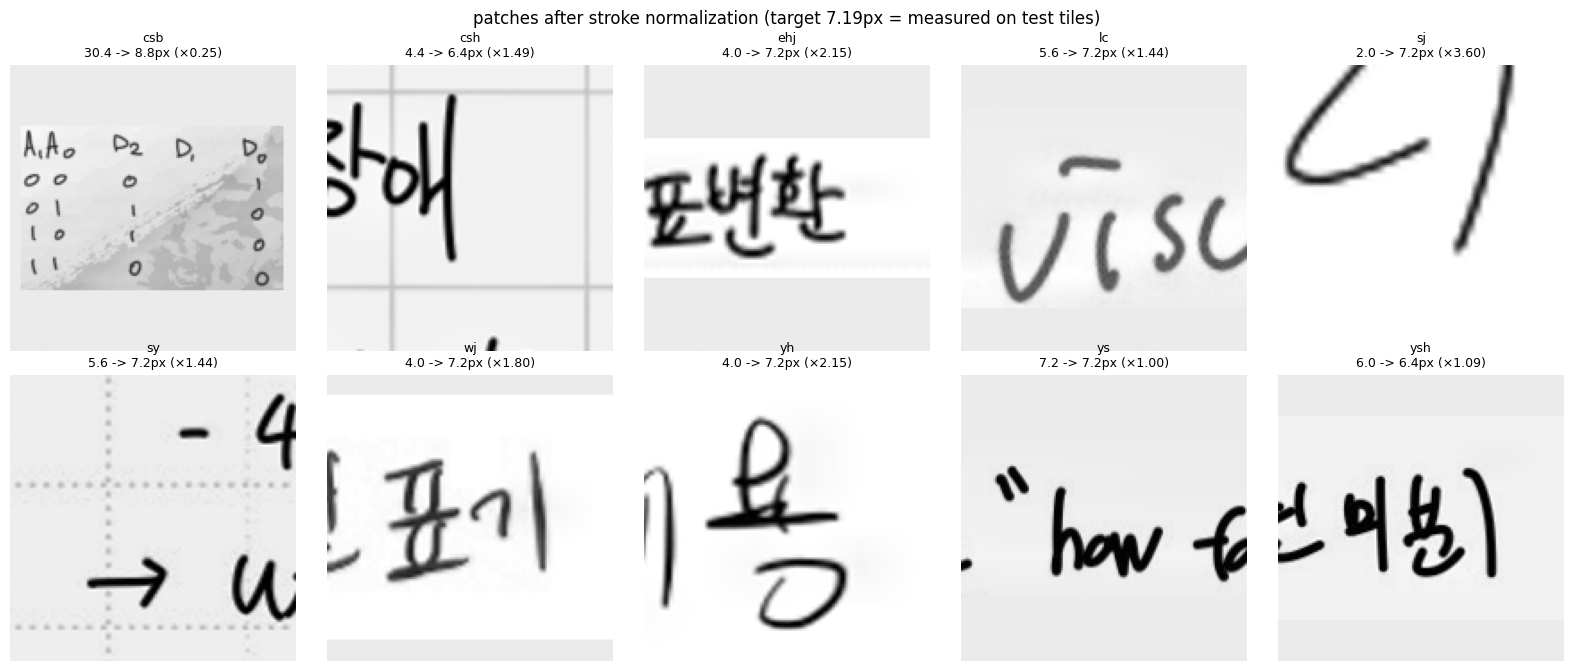

위 10장의 획 굵기가 서로 비슷해 보여야 합니다. 특정 writer만 유독 굵거나 가늘면 그 두께가 곧 정답 단서가 되어 테스트에서 무너집니다.

정규화 후 160px보다 작아 패딩이 필요한 crop: 45.3%

선택된 패치의 잉크 밀도 (목표 0.077 = 테스트 패치 실측):
          ink  flat_bg
writer                
csb     0.079    0.872
csh     0.083    0.854
ehj     0.081    0.902
lc      0.082    0.892
sj      0.076    0.901
sy      0.081    0.835
wj      0.078    0.870
yh      0.079    0.902
ys      0.079    0.902
ysh     0.079    0.894
writer간 잉크 밀도 폭: 0.007  (정규화 전 실측 0.072 = 0.056~0.128)
✅ 잉크 밀도가 충분히 균일해졌습니다.


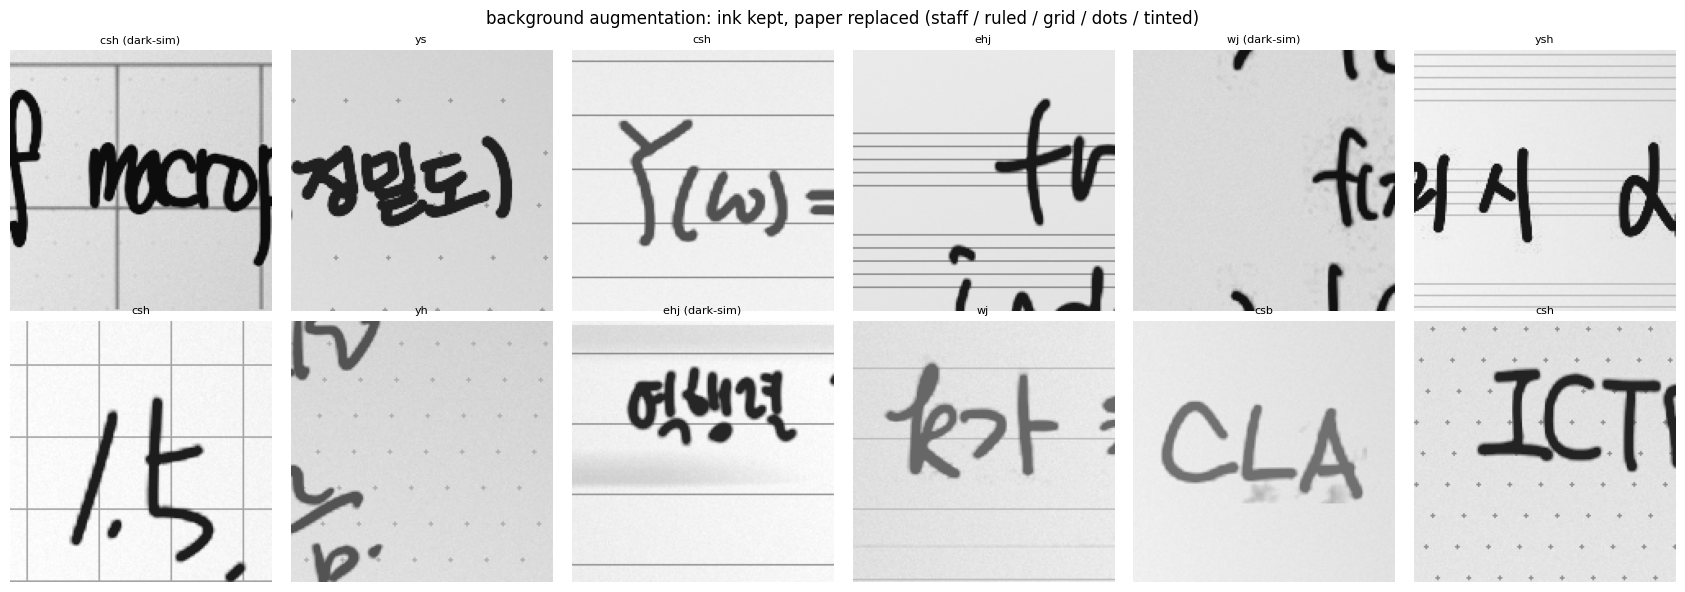

획이 배경 무늬에 묻히지 않고 살아 있어야 합니다. 선이 너무 진하면 SYNTH_BG_P를 낮추세요.


In [22]:
# [8] 패치 육안 검수 — 획 두께가 실제로 균일해졌는지 눈으로 확인한다
fig, axes = plt.subplots(2, 5, figsize=(16, 6.8))
for ax, w in zip(axes.ravel(), CLASSES):
    r = train_df[train_df.writer == w].iloc[0]
    g, _ = to_gray_normalized(cv2.imread(r.path, cv2.IMREAD_COLOR))
    gn = normalize_stroke(g, r.norm_scale, 1.0)
    ax.imshow(take_patches(gn, 1, deterministic=True)[0], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{w}\n{r.stroke_px:.1f} -> {r.stroke_after:.1f}px (×{r.norm_scale:.2f})", fontsize=9)
    ax.axis("off")
# 그래프 안 텍스트는 영문으로 쓴다 — Colab 기본 폰트(DejaVu Sans)에 한글 글리프가 없어
# 한글을 넣으면 제목이 네모로 깨지고 경고가 쏟아진다. 콘솔 출력은 한글 그대로 둔다.
plt.suptitle(f"patches after stroke normalization (target {CFG['TARGET_STROKE_PX']}px = measured on test tiles)")
plt.tight_layout(); plt.savefig(os.path.join(CFG["OUT_DIR"], "patch_preview.png"), dpi=120); plt.show()
print("위 10장의 획 굵기가 서로 비슷해 보여야 합니다. 특정 writer만 유독 굵거나 가늘면 "
      "그 두께가 곧 정답 단서가 되어 테스트에서 무너집니다.")

# 정규화 후 224보다 작아 배경 패딩이 들어가는 비율 — 테스트 타일(512px)에는 없는 특성이라
# 너무 높으면 그 자체가 학습/테스트 차이가 된다.
pad_need = []
for r in train_df.sample(min(150, len(train_df)), random_state=SEED).itertuples():
    g, _ = to_gray_normalized(cv2.imread(r.path, cv2.IMREAD_COLOR))
    gn = normalize_stroke(g, r.norm_scale, 1.0)
    pad_need.append(gn.shape[0] < CFG["PATCH"] or gn.shape[1] < CFG["PATCH"])
pad_rate = float(np.mean(pad_need))
print(f"\n정규화 후 {CFG['PATCH']}px보다 작아 패딩이 필요한 crop: {pad_rate:.1%}")

# 잉크 밀도 정규화 검증 — 획 두께와 같은 방식으로 writer간 편차가 줄었는지 확인한다.
# 패딩은 crop 크기 차이 때문에 없앨 수 없으므로(csb는 128px에서도 87%), 대신 잉크 밀도를
# 맞춰 "얼마나 타이트하게 잘랐는가"가 정답 단서가 되지 않게 한다.
ink_rows = []
for r in train_df.groupby("writer", group_keys=False).head(20).itertuples():
    g, _ = to_gray_normalized(cv2.imread(r.path, cv2.IMREAD_COLOR))
    gn = normalize_stroke(g, r.norm_scale, 1.0)
    for p in take_patches(gn, 3, deterministic=True):
        ink_rows.append(dict(writer=r.writer, ink=float((p < 200).mean()),
                             flat_bg=float((p >= CFG["BG_VALUE"] - 2).mean())))
ink_tbl = pd.DataFrame(ink_rows).groupby("writer").agg(
    ink=("ink", "median"), flat_bg=("flat_bg", "median")).reindex(CLASSES)
print(f"\n선택된 패치의 잉크 밀도 (목표 {CFG['TARGET_INK']} = 테스트 패치 실측):")
print(ink_tbl.round(3).to_string())
spread = ink_tbl.ink.max() - ink_tbl.ink.min()
print(f"writer간 잉크 밀도 폭: {spread:.3f}  (정규화 전 실측 0.072 = 0.056~0.128)")
if spread > 0.040:
    print("⚠️ 잉크 밀도 편차가 큽니다 — 그 차이가 그대로 지름길이 됩니다. "
          "PATCH_CANDIDATES를 늘리거나 PATCH를 줄여보세요.")
else:
    print("✅ 잉크 밀도가 충분히 균일해졌습니다.")

# 배경 증강 미리보기 — 오선/줄/모눈/점/누런 종이가 실제로 붙는지, 획이 살아남는지 확인한다.
fig, axes = plt.subplots(2, 6, figsize=(17, 6))
demo = train_df.sample(min(12, len(train_df)), random_state=SEED).reset_index(drop=True)
for ax, i in zip(axes.ravel(), range(len(demo))):
    r = demo.iloc[i]
    bgr = cv2.imread(r.path, cv2.IMREAD_COLOR)
    dark = i % 4 == 0                                   # 몇 장은 다크모드 촬영을 모사
    g, _ = to_gray_normalized(255 - bgr if dark else bgr)
    g = normalize_stroke(g, r.norm_scale, 1.0)
    patch = take_patches(g, 1, deterministic=True)[0]          # 선택 -> 그 다음 합성
    ax.imshow(synthesize_background(patch, random.Random(SEED + i)), cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{r.writer}{' (dark-sim)' if dark else ''}", fontsize=8)
    ax.axis("off")
plt.suptitle("background augmentation: ink kept, paper replaced (staff / ruled / grid / dots / tinted)")
plt.tight_layout(); plt.savefig(os.path.join(CFG["OUT_DIR"], "bg_aug_preview.png"), dpi=120); plt.show()
print("획이 배경 무늬에 묻히지 않고 살아 있어야 합니다. 선이 너무 진하면 SYNTH_BG_P를 낮추세요.")

In [23]:
# [9] 모델 — ImageNet 사전학습 ConvNeXt-Tiny 전체 미세조정
# ResNet18(v1~v4)은 텍스처 편향이 강한 축의 CNN이다(Geirhos et al., 2019). 이 태스크의
# domain gap이 "종이 잉크 텍스처 vs 태블릿 벡터 렌더링"이라, 텍스처에 덜 의존하고 더
# 넓은 수용영역/전역 구조를 보는 백본이 유리할 수 있다는 가설이다. 순수 ViT는 저데이터
# 미세조정에서 CNN보다 떨어진다는 보고가 많아 제외하고, 트랜스포머적 설계(큰 커널,
# LayerNorm)를 접목한 ConvNeXt-Tiny를 골랐다. 헤드는 v4의 ArcFace가 아니라 v1~v3과
# 같은 단순 Linear+CrossEntropy — 백본 교체 효과만 단독으로 본다.
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, NUM_CLASSES)
model = model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG["EPOCHS"])
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["LABEL_SMOOTHING"])
AMP_DTYPE = torch.bfloat16 if (DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda" and AMP_DTYPE == torch.float16))
print(f"ConvNeXt-Tiny {sum(p.numel() for p in model.parameters())/1e6:.1f}M params | AMP {AMP_DTYPE}")


ResNet18 11.2M params | AMP torch.bfloat16


epoch 1/20:   0%|          | 0/8 [00:00<?, ?it/s]

[01/20] loss 1.7812 | val patch F1 0.1830 | crop acc 0.3058 F1 0.1882 | worst sy 0.000 | 47s  ★ best


epoch 2/20:   0%|          | 0/8 [00:00<?, ?it/s]

[02/20] loss 1.2541 | val patch F1 0.2237 | crop acc 0.3347 F1 0.2956 | worst sy 0.000 | 23s  ★ best


epoch 3/20:   0%|          | 0/8 [00:00<?, ?it/s]

...

[14/20] loss 0.5420 | val patch F1 0.4128 | crop acc 0.5620 F1 0.4527 | worst sy 0.000 | 24s


epoch 15/20:   0%|          | 0/8 [00:00<?, ?it/s]

[15/20] loss 0.5594 | val patch F1 0.3769 | crop acc 0.4793 F1 0.3853 | worst sy 0.000 | 24s


epoch 16/20:   0%|          | 0/8 [00:00<?, ?it/s]

[16/20] loss 0.5528 | val patch F1 0.4066 | crop acc 0.5124 F1 0.4179 | worst sy 0.000 | 23s
조기 종료

최고 val crop macro F1 = 0.5048


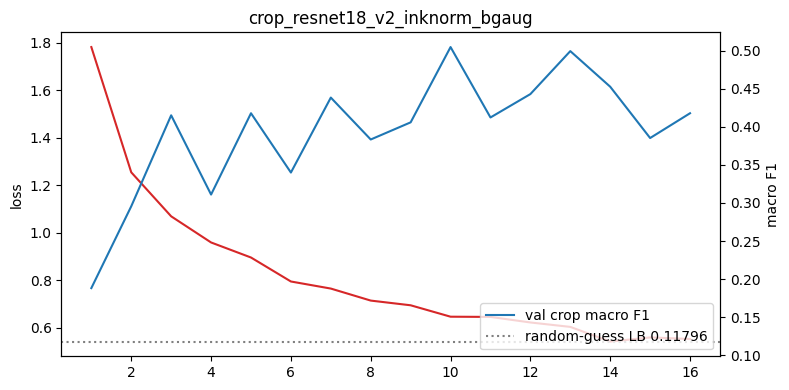

In [24]:
# [10] 학습 — 선택 기준은 val macro F1 (리더보드 지표와 동일)
BEST_PATH = os.path.join(CFG["OUT_DIR"], "best.pt")
LOG_PATH = os.path.join(CFG["OUT_DIR"], "train_log.csv")

@torch.no_grad()
def collect_logits(loader, k):
    model.eval()
    L, Y = [], []
    for xb, yb in loader:
        fx, fy = flatten_batch(xb, yb)
        with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=(DEVICE.type == "cuda")):
            out = model(fx.to(DEVICE, non_blocking=True))
        L.append(out.float().cpu()); Y.append(fy)
    logits, labels = torch.cat(L), torch.cat(Y)
    crop_logits = logits.view(-1, k, NUM_CLASSES).softmax(-1).mean(1)   # crop 단위 집계
    crop_labels = labels.view(-1, k)[:, 0]
    return logits, labels, crop_logits, crop_labels

def metrics(logits, labels):
    pred = logits.argmax(1).numpy(); true = labels.numpy()
    per = f1_score(true, pred, average=None, labels=list(range(NUM_CLASSES)), zero_division=0)
    return dict(acc=accuracy_score(true, pred), macro_f1=float(per.mean()),
                worst=CLASSES[int(per.argmin())], worst_f1=float(per.min()),
                n_pred=len(set(pred.tolist())))

best_f1, patience, history = -1.0, 0, []
for epoch in range(CFG["EPOCHS"]):
    model.train()
    t0, run, seen = time.time(), 0.0, 0
    for xb, yb in tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG['EPOCHS']}", leave=False):
        fx, fy = flatten_batch(xb, yb)
        fx, fy = fx.to(DEVICE, non_blocking=True), fy.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=(DEVICE.type == "cuda")):
            loss = criterion(model(fx), fy)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        run += loss.item() * fy.numel(); seen += fy.numel()
    scheduler.step()

    pl, plab, cl, clab = collect_logits(val_loader, CFG["VAL_PATCHES_PER_CROP"])
    mp, mc = metrics(pl, plab), metrics(cl.clamp_min(1e-12).log(), clab)
    row = dict(epoch=epoch + 1, train_loss=run / max(1, seen), val_patch_macro_f1=mp["macro_f1"],
               val_crop_acc=mc["acc"], val_crop_macro_f1=mc["macro_f1"],
               worst=mc["worst"], worst_f1=mc["worst_f1"], elapsed=time.time() - t0)
    history.append(row); pd.DataFrame(history).to_csv(LOG_PATH, index=False)

    star = ""
    if mc["macro_f1"] > best_f1:
        best_f1, patience, star = mc["macro_f1"], 0, "  ★ best"
        torch.save(dict(model=model.state_dict(), cfg=CFG, classes=CLASSES,
                        epoch=epoch, val_macro_f1=best_f1), BEST_PATH)
    else:
        patience += 1
    print(f"[{epoch+1:02d}/{CFG['EPOCHS']}] loss {row['train_loss']:.4f} | "
          f"val patch F1 {mp['macro_f1']:.4f} | crop acc {mc['acc']:.4f} F1 {mc['macro_f1']:.4f} | "
          f"worst {mc['worst']} {mc['worst_f1']:.3f} | {row['elapsed']:.0f}s{star}")
    if mc["n_pred"] < NUM_CLASSES:
        print(f"  ⚠️ 예측에 등장하지 않은 클래스가 있습니다 ({mc['n_pred']}/10). 그 F1은 0입니다.")
    if patience >= CFG["EARLY_STOP_PATIENCE"]:
        print("조기 종료"); break

print(f"\n최고 val crop macro F1 = {best_f1:.4f}")
h = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(h.epoch, h.train_loss, color="tab:red", label="train_loss"); ax.set_ylabel("loss")
ax2 = ax.twinx()
ax2.plot(h.epoch, h.val_crop_macro_f1, color="tab:blue", label="val crop macro F1")
ax2.axhline(RANDOM_FLOOR_LB, color="gray", ls=":", label=f"random-guess LB {RANDOM_FLOOR_LB}")
ax2.set_ylabel("macro F1"); ax2.legend(loc="lower right")
plt.title(CFG["RUN_NAME"]); plt.tight_layout(); plt.show()

체크포인트: epoch 10, val macro F1 0.5048

              precision    recall  f1-score   support

         csb      0.642     0.586     0.613        58
         csh      1.000     0.900     0.947        10
         ehj      0.596     0.824     0.691        34
          lc      0.433     0.784     0.558        37
          sj      0.375     1.000     0.545         3
          sy      0.000     0.000     0.000         6
          wj      0.667     0.640     0.653        25
          yh      0.000     0.000     0.000        19
          ys      0.500     0.176     0.261        17
         ysh      0.885     0.697     0.780        33

    accuracy                          0.599       242
   macro avg      0.510     0.561     0.505       242
weighted avg      0.574     0.599     0.567       242



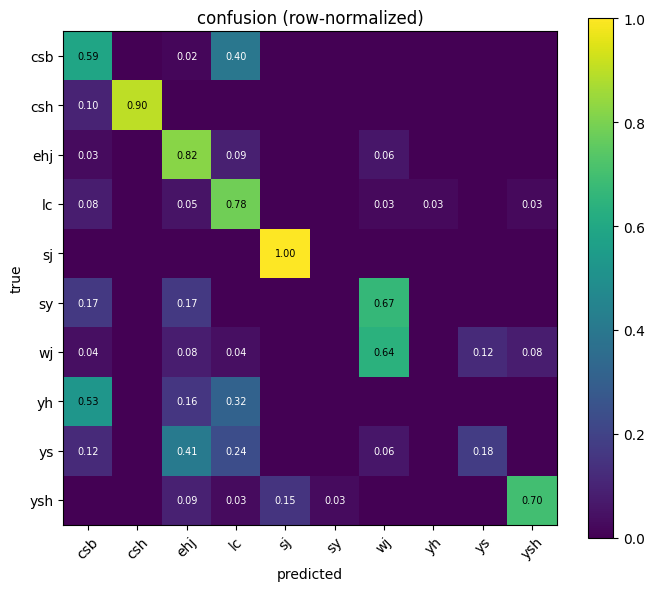

세션 홀드아웃            crop  208 | acc 0.562 | macro F1 0.490 (writer 9명 기준) | ['csb', 'csh', 'lc', 'sj', 'sy', 'wj', 'yh', 'ys', 'ysh']
crop 단위(낙관적)       crop   34 | acc 0.824 | macro F1 0.903 (writer 1명 기준) | ['ehj']

세션 홀드아웃 쪽 숫자만 리더보드와 성격이 비슷합니다. 참고: 균등 무작위 LB = 0.11796


In [26]:
# [11] 검증 상세 — 클래스별 F1과 혼동 행렬
ck = torch.load(BEST_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ck["model"])
print(f"체크포인트: epoch {ck['epoch']+1}, val macro F1 {ck['val_macro_f1']:.4f}")

_, _, cl, clab = collect_logits(val_loader, CFG["VAL_PATCHES_PER_CROP"])
pred = cl.argmax(1).numpy(); true = clab.numpy()
print("\n" + classification_report(true, pred, labels=list(range(NUM_CLASSES)),
                                    target_names=CLASSES, zero_division=0, digits=3))

cm = confusion_matrix(true, pred, labels=list(range(NUM_CLASSES)), normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES), CLASSES, rotation=45); ax.set_yticks(range(NUM_CLASSES), CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("confusion (row-normalized)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm[i, j] > 0.01:
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] < 0.5 else "black")
fig.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(CFG["OUT_DIR"], "confusion_matrix.png"), dpi=120); plt.show()

# 세션 홀드아웃 val인지 crop 단위 val인지에 따라 낙관 정도가 다르다 — 나눠서 본다.
val_eval = val_df.copy(); val_eval["pred"] = pred; val_eval["correct"] = pred == true
for flag, name in ((True, "세션 홀드아웃"), (False, "crop 단위(낙관적)")):
    sub = val_eval[val_eval.session_holdout == flag]
    if len(sub):
        # macro F1은 그 부분집합에 실제로 존재하는 writer에 대해서만 평균한다.
        # 10개 클래스 전체로 평균하면 writer 1명짜리 부분집합의 F1이 1/10로 눌려 오해를 부른다.
        present = sorted(sub.label.unique())
        f1 = f1_score(sub.label, sub.pred, average="macro", labels=present, zero_division=0)
        print(f"{name:18s} crop {len(sub):4d} | acc {sub.correct.mean():.3f} | "
              f"macro F1 {f1:.3f} (writer {len(present)}명 기준) | {sorted(sub.writer.unique())}")
print(f"\n세션 홀드아웃 쪽 숫자만 리더보드와 성격이 비슷합니다. "
      f"참고: 균등 무작위 LB = {RANDOM_FLOOR_LB}")

test:   0%|          | 0/490 [00:00<?, ?it/s]

  ✅ 행 수 490
  ✅ 컬럼
  ✅ id 순서
  ✅ label 정수/범위

테스트 타일 획 두께: 정규화 전 6.39px -> 후 7.19px (목표 7.19px)
테스트 패치 잉크 밀도 0.0778 (목표 0.077) | 다크모드 12.2%
예측 분포: 최대 ysh 39.4% | 예측 0회 1개
  ❌ 한 번도 예측되지 않음: ['sy'] -> macro F1 상한 0.90

제출 시 비교 기준: 균등 무작위 LB = 0.11796. 이보다 0.02 넘게 높지 않으면 개선으로 보지 않는다.


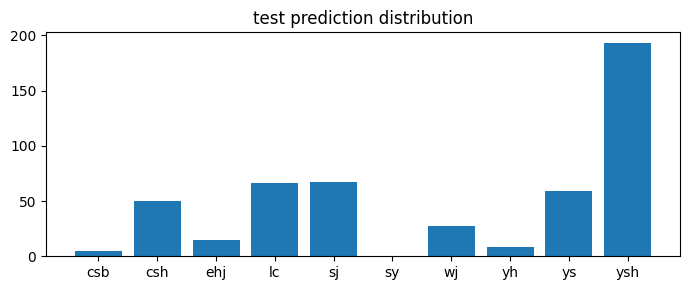

submission: /content/outputs_crop_resnet18_v2_inknorm_bgaug/submission.csv


In [27]:
# [12] 테스트 추론 · 제출 생성
# CRITICAL: 복호화된 픽셀을 표시하거나 저장하지 않는다 (대회 규칙, 실격 사유).
#           출력은 통계량과 예측 인덱스뿐이다.
sample = pd.read_csv(SAMPLE_SUB, dtype={"id": str})
if not os.path.exists(CFG["TEST_LOADER_PATH"]):
    raise FileNotFoundError(f"❌ test_loader.ipynb를 Drive에 두세요: {CFG['TEST_LOADER_PATH']}")

def load_test_loader(path):
    """대회가 제공한 노트북에서 TestDS 정의까지만 실행한다. 자체 복호화는 구현하지 않는다."""
    nb = json.load(open(path, encoding="utf-8"))
    ns = {"__name__": "competition_test_loader"}
    for cell in nb.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        src = "".join(cell.get("source", []))
        exec(compile(src, path, "exec"), ns)
        if "class TestDS" in src:
            return ns
    raise AttributeError("❌ test_loader.ipynb에서 TestDS를 찾지 못했습니다.")

tl = load_test_loader(CFG["TEST_LOADER_PATH"])
assert list(tl["CLASSES"]) == CLASSES, f"클래스 순서 불일치: {tl['CLASSES']}"
ds = tl["TestDS"](sample.id.tolist(), DATA_ROOT, transform=None)
assert len(ds) == len(sample), f"TestDS {len(ds)} != sample {len(sample)}"

model.eval()
probs, tile_stats = [], []
with torch.no_grad():
    for i in tqdm(range(len(ds)), desc="test"):
        im, _ = ds[i]
        rgb = np.asarray(im)
        if rgb.ndim == 2:
            rgb = np.stack([rgb] * 3, -1)
        g, inv = to_gray_normalized(cv2.cvtColor(rgb[..., :3], cv2.COLOR_RGB2BGR))
        s = measure_stroke_px(g)
        # 학습 crop과 정확히 같은 함수로 배율을 구해 같은 방식으로 적용한다.
        # 이 대칭이 이 파이프라인의 전부이며, 깨지면 이전 시도들처럼 무작위로 돌아간다.
        gn = normalize_stroke(g, fit_norm_scale(g), 1.0)
        patches = take_patches(gn, CFG["TEST_PATCHES_PER_TILE"], deterministic=True)
        xb = torch.stack([eval_tf(Image.fromarray(p)) for p in patches]).to(DEVICE)
        with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=(DEVICE.type == "cuda")):
            out = model(xb)
        probs.append(out.float().softmax(-1).mean(0).cpu())
        tile_stats.append(dict(stroke_px=s, stroke_after=measure_stroke_px(gn), inverted=inv,
                               ink_ratio=float((g < 200).mean()),
                               patch_ink=float(np.mean([(p < 200).mean() for p in patches]))))

probs = torch.stack(probs)
labels = probs.argmax(1).numpy().astype(int)
submission = pd.DataFrame({"id": sample.id.values, "label": labels})

checks = {"행 수 490": len(submission) == 490,
          "컬럼": list(submission.columns) == ["id", "label"],
          "id 순서": submission.id.tolist() == sample.id.tolist(),
          "label 정수/범위": pd.api.types.is_integer_dtype(submission.label) and submission.label.between(0, 9).all()}
for k, v in checks.items():
    print(f"  {'✅' if v else '❌'} {k}")
if not all(checks.values()):
    raise RuntimeError("❌ 제출 형식 검증 실패 — 파일을 쓰지 않습니다.")
sub_path = os.path.join(CFG["OUT_DIR"], "submission.csv")
submission.to_csv(sub_path, index=False)

# ---- 진단: 도메인 정합 + 예측 붕괴 ----
ts = pd.DataFrame(tile_stats)
print("\n" + "=" * 66)
# 정규화 '후' 값을 반드시 함께 본다. 이전에는 정규화 전 값만 찍혀 대칭이 맞는지 알 수 없었다.
print(f"테스트 타일 획 두께: 정규화 전 {ts.stroke_px.median():.2f}px -> "
      f"후 {ts.stroke_after.median():.2f}px (목표 {CFG['TARGET_STROKE_PX']}px)")
print(f"테스트 패치 잉크 밀도 {ts.patch_ink.median():.4f} (목표 {CFG['TARGET_INK']}) | "
      f"다크모드 {ts.inverted.mean():.1%}")
if abs(ts.stroke_after.median() - CFG["TARGET_STROKE_PX"]) > 0.5:
    print("⚠️ 테스트 타일이 목표 획 두께에 수렴하지 않았습니다 — 학습과 배율이 어긋납니다.")
dist = submission.label.value_counts().reindex(range(NUM_CLASSES), fill_value=0)
never = [CLASSES[c] for c in range(NUM_CLASSES) if dist[c] == 0]
top = float(dist.max()) / len(submission)
print(f"예측 분포: 최대 {CLASSES[int(dist.idxmax())]} {top:.1%} | 예측 0회 {len(never)}개")
if never:
    print(f"  ❌ 한 번도 예측되지 않음: {never} -> macro F1 상한 {1 - len(never)/NUM_CLASSES:.2f}")
if top > 0.40:
    print(f"  ❌ 한 클래스가 {top:.1%} — 무작위(LB {RANDOM_FLOOR_LB})보다 낮아질 수 있는 붕괴 신호")
if not never and top <= 0.40:
    print("  ✅ 분포 붕괴 신호 없음")
print(f"\n제출 시 비교 기준: 균등 무작위 LB = {RANDOM_FLOOR_LB}. "
      "이보다 0.02 넘게 높지 않으면 개선으로 보지 않는다.")
print("=" * 66)

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(CLASSES, dist.values); ax.set_title("test prediction distribution")
plt.tight_layout(); plt.savefig(os.path.join(CFG["OUT_DIR"], "prediction_distribution.png"), dpi=120); plt.show()
ts.to_csv(os.path.join(CFG["OUT_DIR"], "test_tile_stats.csv"), index=False)
print("submission:", sub_path)

In [28]:
# [13] Drive 백업 — 런타임이 끊기면 /content는 사라진다
if os.path.isdir("/content/drive"):
    os.makedirs(CFG["DRIVE_OUT_DIR"], exist_ok=True)
    for f in sorted(glob.glob(os.path.join(CFG["OUT_DIR"], "*"))):
        if os.path.isfile(f):
            shutil.copy2(f, os.path.join(CFG["DRIVE_OUT_DIR"], os.path.basename(f)))
    print("백업 완료:", CFG["DRIVE_OUT_DIR"])

meta = dict(run_name=CFG["RUN_NAME"], config=CFG, best_val_macro_f1=float(ck["val_macro_f1"]),
            best_epoch=int(ck["epoch"]) + 1, n_train_crops=int(len(train_df)),
            n_val_crops=int(len(val_df)), random_floor_lb=RANDOM_FLOOR_LB,
            val_session_holdout_frac=float(val_df.session_id.notna().mean()),
            submitted_at=None, leaderboard_score=None)
with open(os.path.join(CFG["OUT_DIR"], "run_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False, default=str)
print("\n제출 후 run_meta.json의 leaderboard_score에 점수를 적어두면 "
      "설정과 점수를 나중에 짝지을 수 있습니다.")

백업 완료: /content/drive/MyDrive/AIKUTHON/outputs_crop_resnet18_v2_inknorm_bgaug

제출 후 run_meta.json의 leaderboard_score에 점수를 적어두면 설정과 점수를 나중에 짝지을 수 있습니다.
